#  Módulo 1 Utilización, procesamiento y visualización de grandes volúmenes de datos (Portafolio Análisis)

##Inteligencia artificial avanzada para la ciencia de datos II (Gpo 501)

# Clasificación de sentimientos de reseñas de Amazon (US)
Dataset tomado de: https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews/

Este notebook presenta una implementación de una regresión logística, que se emplea para clasificar de manera binaria si una reseña es negativa o positiva.

Se seleccionó y descargó un dataset de reseñas de productos en la página web de Amazon.com, con un total de 4,000,000 reseñas correspondientes a distintos productos.

El dataset inicial contiene tres columnas sin titulo, que corresponden a los siguientes datos:
- polarity (valor 1 si es una reseña negativa, 2 si es postiva)
- title (título de la reseña)
- text (contenido de la reseña)

## ETL y Entrenamiento

El primer paso consistió en una instalación de Apache Spark, en su versión 3.5.7, junto con la configuración de sus variables de entorno. Posteriormente, se importarton las dependencias necesarias y se creó una sesión de Spark.

In [1]:
# 0) Prerrequisitos para utilizar Spark
!sudo apt update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz
!tar xf spark-3.5.7-bin-hadoop3.tgz

# Variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.7-bin-hadoop3"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "bin")
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "sbin")


# 1) Instalación de PySpark
!pip install matplotlib pandas --quiet
!pip install -q findspark
!pip install pyspark

# 2) Importar librerías y montar Google Drive
from google.colab import drive
import tarfile
import findspark
import pandas as pd
import seaborn as sns
from pyspark import SparkConf
from pyspark.ml import Pipeline
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType
from sklearn.metrics import confusion_matrix
from pyspark.ml.feature import StopWordsRemover
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import size, col, when, explode, desc
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, SQLTransformer

import matplotlib.pyplot as plt
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Inteligencia Artificial/Big Data
%ls

findspark.init()
findspark.find()

conf = (SparkConf()
    .setAppName("OptimizedPipeline")
    .setMaster("local[*]")
    .set("spark.driver.memory", "8g")
    .set("spark.executor.memory", "8g")
    .set("spark.sql.shuffle.partitions", "4")
    .set("spark.default.parallelism", "4")
)


# 3) Crear sesión Spark
spark_session = SparkSession.builder.config(conf=conf).appName("Reto_Modulo_1").getOrCreate()
spark_session
print("Sesión Spark creada")

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,153 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Pa

El dataset original se encuentra en formato .tgz, por lo que se procedió a descomprimirlo. Este paso solo se requiere correr una vez, y, una vez terminado este paso, nos devuelve dos archivos, un **train.csv**, con un peso de 1.48GB, y un **test.csv**, con un tamaño de 167MB.

In [2]:
# 4) Descomprimir el archivo .tgz
# SOLO CORRER UNA VEZ!

# reviews = tarfile.open('amazon_review_polarity_csv.tgz')
# reviews.extractall()
# reviews.close()

%ls

amazon_review_polarity_csv/
amazon_review_polarity_csv.tgz
df_train_spark3/
model_summary.csv
model_summary.gsheet
model_summary_v3.csv
model_summary_v5.csv
sentiment_predictions_for_tableau.csv
sentiment_predictions_for_tableau_v3.csv
sentiment_predictions_for_tableau_v4.csv
sentiment_predictions_for_tableau_v6.csv
spark-3.5.1-bin-hadoop3/
spark-3.5.1-bin-hadoop3.tgz
spark-3.5.7-bin-hadoop3/
spark-3.5.7-bin-hadoop3.tgz
spark-3.5.7-bin-hadoop3.tgz.1
spark-3.5.7-bin-hadoop3.tgz.2
word_frequency_table.csv
word_frequency_table_v6.csv


Dado que el dataset ya viene separado en archivos de train y test, con 3,600,000 y 400,000 registros, respectivamente.

Dado que son demasiados registros para una instancia de Colab Free, se opta por entrenar el modelo con 100,000 reseñas, tomando un grupo de prueba de 50,000 reseñas más. Esto puede aumentarse fácilmente si el modelo corre durante más tiempo.

In [3]:
df_train = spark_session.read.csv('amazon_review_polarity_csv/train.csv', header=False, inferSchema=True)
df_test = spark_session.read.csv('amazon_review_polarity_csv/test.csv', header=False, inferSchema=True)

# 5) Eliminar datos con celdas vacías
df_train = df_train.dropna()
df_test = df_test.dropna()

# Tomaremos un conjunto de datos más manejable para Colab Free
df_train = df_train.limit(100000)
df_test = df_test.limit(50000)

# 6) Inspección rápida de train y test
df_train.printSchema()
print("-----------------------\n")
df_train.show()
print("-----------------------\n")
df_train.describe().show()

df_test.printSchema()
print("-----------------------\n")
df_test.show()
print("-----------------------\n")
df_test.describe().show()

root
 |-- _c0: integer (nullable = true)
 |-- _c1: string (nullable = true)
 |-- _c2: string (nullable = true)

-----------------------

+---+--------------------+--------------------+
|_c0|                 _c1|                 _c2|
+---+--------------------+--------------------+
|  2|Stuning even for ...|This sound track ...|
|  2|The best soundtra...|I'm reading a lot...|
|  2|            Amazing!|"This soundtrack ...|
|  2|Excellent Soundtrack|I truly like this...|
|  2|Remember, Pull Yo...|If you've played ...|
|  2|an absolute maste...|I am quite sure a...|
|  1|        Buyer beware|"This is a self-p...|
|  2|      Glorious story|I loved Whisper o...|
|  2|    A FIVE STAR BOOK|I just finished r...|
|  2|Whispers of the W...|This was a easy t...|
|  1|          The Worst!|A complete waste ...|
|  2|          Great book|This was a great ...|
|  2|          Great Read|I thought this bo...|
|  1|           Oh please|I guess you have ...|
|  1|Awful beyond belief!|"I feel I have to...|

Puesto que el modelo solo verá las reseñas, no se le dará un uso a la columna de títulos, por lo que se procede a eliminar.

In [4]:
#7) Eliminar columna de título de la reseña, pues no se utiliza
df_train = df_train.drop("_c1")
df_train.show()

df_test = df_test.drop("_c1")
df_test.show()

+---+--------------------+
|_c0|                 _c2|
+---+--------------------+
|  2|This sound track ...|
|  2|I'm reading a lot...|
|  2|"This soundtrack ...|
|  2|I truly like this...|
|  2|If you've played ...|
|  2|I am quite sure a...|
|  1|"This is a self-p...|
|  2|I loved Whisper o...|
|  2|I just finished r...|
|  2|This was a easy t...|
|  1|A complete waste ...|
|  2|This was a great ...|
|  2|I thought this bo...|
|  1|I guess you have ...|
|  1|"I feel I have to...|
|  1|It's glaringly ob...|
|  2|"When you hear fo...|
|  2|After I had a DVT...|
|  2|Excellent product...|
|  1|sizes are much sm...|
+---+--------------------+
only showing top 20 rows

+---+--------------------+
|_c0|                 _c2|
+---+--------------------+
|  2|"My lovely Pat ha...|
|  2|Despite the fact ...|
|  1|I bought this cha...|
|  2|Check out Maha En...|
|  2|Reviewed quite a ...|
|  1|I also began havi...|
|  1|I love the style ...|
|  1|I cannot scroll t...|
|  2|"Exotic tales of ...|
| 

Este conjunto de modificaciones nos permite acelerar el entrenamiento del modelo, manteniendo al mismo tiempo un gran volumen de datos.

Finalmente, se renombran las dos columnas restantes, "_c0", se renombra a Rating, y "_c2" pasa a ser Review, y se ajusta el sistema de calificación de los Ratings, ahora, un Rating negativo tendrá un score de 0 (anteriormente 1), mientras que una reseña positiva ahora tiene un score de 1 (anteriormente 2).

In [5]:
# 8) Renombrar columnas
df_train = df_train.withColumnRenamed("_c0", "Rating").withColumnRenamed("_c2", "Review")
df_train = df_train.withColumn(
    "Rating", when(col("Rating") == 1, 0).otherwise(1).cast(DoubleType())
)

df_test = df_test.withColumnRenamed("_c0", "Rating").withColumnRenamed("_c2", "Review")
df_test = df_test.withColumn(
    "Rating", when(col("Rating") == 1, 0).otherwise(1).cast(DoubleType())
)

Esta sección es opcional, pero nos permite exportar el dataframe actual para saltar esta sección en ejecuciones futuras.

In [6]:
# 9) Exportar DF a CSV usando Spark
#df_train.write.csv('df_train_spark3', header=True, mode='overwrite')

Primero, se almacena en caché el conjunto de datos de entrenamiento y prueba ( utilizando .cache()) para mejorar la velocidad de acceso durante las operaciones repetidas. Luego, se construye un pipeline de procesamiento de texto que incluye tokenización, transformación TF-IDF y el modelo de regresión logística. Además, se define un grid de parámetros para optimizar el modelo mediante validación cruzada, utilizando un enfoque eficiente con paralelismo para minimizar el consumo de recursos. Finalmente, el modelo se entrena aplicando el pipeline completo al conjunto de datos de entrenamiento.

In [7]:
df_train.cache() #Mayor velocidad

# Creación del pipeline completo para NLP
tokenizer = Tokenizer(inputCol="Review", outputCol="words")

# Eliminación de stopwords
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

# TF-IDF
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=5000)
idf = IDF(inputCol="rawFeatures", outputCol="features", minDocFreq=5)

#Modelo de regresión logística
lr = LogisticRegression(featuresCol="features", labelCol="Rating", maxIter=50)

pipeline = Pipeline(stages=[tokenizer, stopwords_remover, hashingTF, idf, lr])

# Grid de parámetros, poco consumo de recursos
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1])
             .addGrid(lr.elasticNetParam, [0.0, 0.5])
             .build())

# CrossValidator optimizado con paralelismo y bajo uso de recursos
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol="Rating"),
    numFolds=2,
    parallelism=2    # usa 2 hilos locales
)

# Entrenamiento del modelo
cvModel = crossval.fit(df_train)


In [8]:
df_test.cache() #Mayor velocidad

# Evaluación con datos de prueba
# El cvModel ya contiene todas las transformaciones del pipeline
# Solo necesitamos aplicar el modelo completo a los datos de prueba
predictions = cvModel.transform(df_test)

## Estadísticas del dataset

En esta sección, se realiza un análisis detallado del conjunto de datos para comprender mejor su estructura y características. Este análisis es crucial para garantizar que los datos sean adecuados para el modelo y para identificar posibles problemas que puedan afectar el rendimiento del mismo.

### Objetivos del análisis:
1. **Distribución de clases:**
   - Se analiza la proporción de reseñas positivas y negativas en el conjunto de entrenamiento. Esto es importante para detectar posibles desbalances en las clases, lo que podría influir en el desempeño del modelo.

2. **Longitud de las reseñas:**
   - Se calcula la longitud promedio de las reseñas en términos de número de palabras (tokens). Esto ayuda a entender la complejidad del texto y a ajustar los parámetros del modelo, como el número de características en el vectorizador.

3. **Palabras más comunes:**
   - Se identifican las palabras más frecuentes en las reseñas. Este análisis puede proporcionar información sobre los términos más representativos y su relación con las clases objetivo.

4. **Comparación por clase:**
   - Se comparan las características de las reseñas (como su longitud) entre las clases positivas y negativas. Esto puede revelar patrones específicos que el modelo podría aprovechar.

El análisis descriptivo no solo ayuda a validar la calidad de los datos, sino que también proporciona información valiosa para ajustar el modelo y mejorar su desempeño.

### Uso de métricas adicionales para evaluar el desempeño del modelo

Se emplean las siguientes métricas para evaluar el modelo:

- **Curva ROC (AUC):** Evalúa la capacidad del modelo para distinguir entre clases.
- **Precisión:** Proporción de predicciones correctas entre todas las predicciones positivas.
- **Recall:** Proporción de verdaderos positivos entre todos los positivos reales.
- **F1-Score:** Media armónica entre precisión y recall, útil para datos desbalanceados.

Estas métricas proporcionan una visión integral del desempeño del modelo.

In [9]:
# Selección segura de la columna de etiqueta (label)
label_col = "label" if "label" in predictions.columns else "Rating"

from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

# Evaluar modelo usando BinaryClassificationEvaluator
binary_evaluator = BinaryClassificationEvaluator(
    labelCol=label_col,
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = binary_evaluator.evaluate(predictions)
print(f"Area Under ROC (AUC) en datos de prueba = {auc}")

# Preparación de los datos para MulticlassMetrics, que recibe un RDD con (prediction, label)
predictionAndLabels = predictions.select("prediction", label_col).rdd.map(
    lambda row: (float(row["prediction"]), float(row[label_col]))
)

# Instancia del objeto de métricas
metrics = MulticlassMetrics(predictionAndLabels)

# Métricas globales
accuracy = metrics.accuracy
print(f"Exactitud (Accuracy) en datos de prueba = {accuracy}")

# Estadísticas por clase
# Para clasificación binaria, metrics.precision(1.0), metrics.recall(1.0) y metrics.fMeasure(1.0) corresponden a la clase positiva (etiqueta 1),
# y metrics.precision(0.0), metrics.recall(0.0) y metrics.fMeasure(0.0) corresponden a la clase negativa (etiqueta 0).
positive_class_label = 1.0
negative_class_label = 0.0

precision_pos = metrics.precision(positive_class_label)
recall_pos = metrics.recall(positive_class_label)
f1_pos = metrics.fMeasure(positive_class_label)

precision_neg = metrics.precision(negative_class_label)
recall_neg = metrics.recall(negative_class_label)
f1_neg = metrics.fMeasure(negative_class_label)

print(f"\nMétricas para la Clase Positiva (etiqueta {int(positive_class_label)}):")
print(f"  Precisión = {precision_pos}")
print(f"  Exhaustividad (Recall) = {recall_pos}")
print(f"  F1-Score = {f1_pos}")

print(f"\nMétricas para la Clase Negativa (etiqueta {int(negative_class_label)}):")
print(f"  Precisión = {precision_neg}")
print(f"  Exhaustividad (Recall) = {recall_neg}")
print(f"  F1-Score = {f1_neg}")

Area Under ROC (AUC) en datos de prueba = 0.8823286993746463


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Exactitud (Accuracy) en datos de prueba = 0.80226

Métricas para la Clase Positiva (etiqueta 1):
  Precisión = 0.7922626910737876
  Exhaustividad (Recall) = 0.8272641286356113
  F1-Score = 0.8093851819005572

Métricas para la Clase Negativa (etiqueta 0):
  Precisión = 0.8135290363752393
  Exhaustividad (Recall) = 0.7764963859335662
  F1-Score = 0.7945814547796639

Matriz de confusión:
[[19122.  5504.]
 [ 4383. 20991.]]


In [10]:
# Agrupar y contar por el Rating
rating_counts = df_train.groupBy("Rating").count()

# Transformar a DF de Pandas para imprimir de manera amigable
rating_counts_pandas = rating_counts.toPandas()

print("Distribución de clases:")
display(rating_counts_pandas)

Distribución de clases:


,Rating,count
0,1.0,51267
1,0.0,48733


In [11]:
# Volver a tokenizar el texto para recuperar la columna 'words'
tokenizer = Tokenizer(inputCol="Review", outputCol="words")
df_train_with_words = tokenizer.transform(df_train)

# Calcular la longitud de cada reseña en número de tokens
df_train_with_token_length = df_train_with_words.withColumn("Review_Token_Length", size(col("words")))

# Calcular estadísticas descriptivas de las longitudes de las reseñas
review_length_stats = df_train_with_token_length.select("Review_Token_Length").describe()

# Imprimir las estadísticas
print("Estadísticas descriptivas para la longitud (en tokens) de las reseñas:")
review_length_stats.show()

Estadísticas descriptivas para la longitud (en tokens) de las reseñas:
+-------+-------------------+
|summary|Review_Token_Length|
+-------+-------------------+
|  count|             100000|
|   mean|           67.10845|
| stddev|  40.16910061432704|
|    min|                  1|
|    max|                240|
+-------+-------------------+



### Matriz de confusión

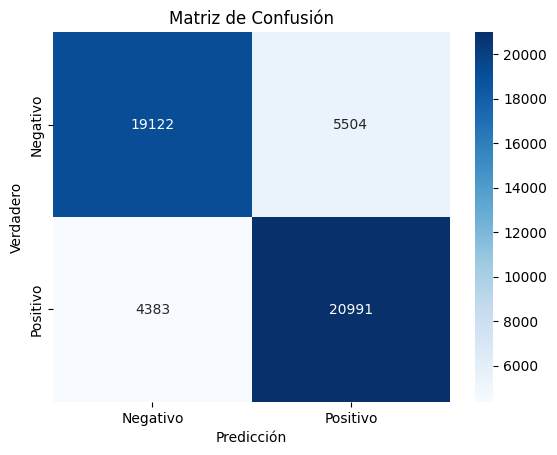

In [13]:
# Matriz de confusión
label_col = "Rating" # Asegúrate de que esta variable apunte a la columna correcta
y_true = predictions.select(label_col).toPandas()
y_pred = predictions.select("prediction").toPandas()

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

La matriz de confusión es una herramienta esencial para evaluar el rendimiento de un modelo de clasificación. Proporciona una representación visual de las predicciones del modelo en comparación con las etiquetas reales, permitiendo identificar patrones de errores y aciertos.

En este caso, la matriz de confusión se genera utilizando las 50,000 reseñas del conjunto de prueba. Podemos observar que el modelo clasifica correctamente 20,991 reseñas positivas y 19,122 reseñas negativas. Sin embargo, también comete errores, clasificando incorrectamente 5504 reseñas negativas como positivas y 4383 reseñas positivas como negativas.

### Comparar el recuento de palabras por clase

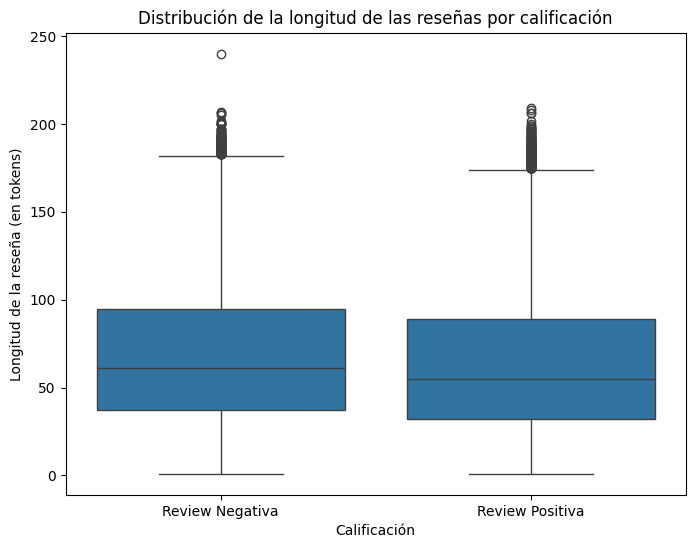

In [23]:
# Convertir el DataFrame de PySpark a un DataFrame de Pandas
df_train_with_token_length_pandas = df_train_with_token_length.select("Rating", "Review_Token_Length").toPandas()

# Calcular estadísticas descriptivas por clase
print("Estadísticas de longitud de reseñas por calificación:")
print("\nReseñas Negativas (Rating = 0):")
print(df_train_with_token_length_pandas[df_train_with_token_length_pandas["Rating"] == 0]["Review_Token_Length"].describe())
print("\nReseñas Positivas (Rating = 1):")
print(df_train_with_token_length_pandas[df_train_with_token_length_pandas["Rating"] == 1]["Review_Token_Length"].describe())

# Crear un diagrama de caja (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Rating", y="Review_Token_Length", data=df_train_with_token_length_pandas)

# Establecer etiquetas personalizadas para el eje X
plt.xticks([0, 1], ['Review Negativa', 'Review Positiva'])

# Agregar título y etiquetas
plt.title("Distribución de la longitud de las reseñas por calificación")
plt.xlabel("Calificación")
plt.ylabel("Longitud de la reseña (en tokens)")

# Mostrar gráfico
plt.show()

Con este análisis, podemos observar que las reseñas negativas tienden a ser más largas en promedio (con una longitud media de 69.62 tokens) en comparación con las reseñas positivas (con una longitud media de 64.71 tokens). La desviación estándar también es ligeramente mayor para las reseñas negativas, lo que indica una mayor variabilidad en la longitud de estas reseñas.

### Encontrar las palabras más comunes

In [16]:
# Aplicar un flatten la columna 'words'
word_counts = df_train_with_words.select(explode("words").alias("word"))

# Contar la frecuencia de cada palabra
word_counts = word_counts.groupBy("word").count()

# Ordenar por conteo en orden descendente y mostrar las 20 más frecuentes
most_common_words = word_counts.orderBy(desc("count"))
print("20 palabras con más apariciones:")
most_common_words.show(20, truncate=False)

# Convertir el DataFrame de PySpark a Pandas DataFrame para poder usar .to_csv
word_freq_pandas = most_common_words.toPandas()

# Guardar en un nuevo archivo CSV
word_freq_pandas.to_csv("word_frequency_table_v6.csv", index=False)

20 palabras con más apariciones:
+----+------+
|word|count |
+----+------+
|the |345388|
|and |184005|
|i   |173121|
|a   |170290|
|to  |163710|
|of  |141133|
|this|124890|
|is  |123966|
|it  |116986|
|in  |81176 |
|that|67695 |
|for |66806 |
|was |64143 |
|you |49126 |
|with|47583 |
|but |46668 |
|not |46475 |
|on  |44212 |
|have|43998 |
|my  |41082 |
+----+------+
only showing top 20 rows



Se observa que las palabras más comunes en las reseñas resultan ser "conectores" o palabras funcionales, como "the", "and", "is", "it", "to", entre otras. Estas palabras no aportan un significado significativo al análisis de sentimientos y, por lo tanto, se consideran ruido en el contexto del procesamiento de lenguaje natural (NLP).

### Resumen de la ejecución

In [17]:
# Collect the evaluation metrics
metrics_summary = {
    "AUC": auc,
    "Precisión global": accuracy,
    "Precisión clase positiva": precision_pos,
    "Recall clase positiva": recall_pos,
    "Puntaje F1 clase positiva": f1_pos,
    "Precisión clase negativa": precision_neg,
    "Recall clase negativa": recall_neg,
    "Puntaje F1 clase negativa": f1_neg
}

# Imprimir el diccionario para verificar las métricas recopiladas
print(metrics_summary)

{'AUC': 0.8823286993746463, 'Precisión global': 0.80226, 'Precisión clase positiva': 0.7922626910737876, 'Recall clase positiva': 0.8272641286356113, 'Puntaje F1 clase positiva': 0.8093851819005572, 'Precisión clase negativa': 0.8135290363752393, 'Recall clase negativa': 0.7764963859335662, 'Puntaje F1 clase negativa': 0.7945814547796639}


In [18]:
# Convert the Spark DataFrames to a format suitable

# Agrupar y contar por el Rating'
rating_counts = df_train.groupBy("Rating").count()

# Transformar a DF de Pandas para imprimir de manera amigable
rating_counts_pandas = rating_counts.toPandas()

rating_counts_list = rating_counts_pandas.to_dict('records')
review_length_stats_list = review_length_stats.toPandas().to_dict('records')
most_common_words_list = most_common_words.limit(20).toPandas().to_dict('records')

# Crear el diccionario de resumen completo del modelo
model_summary = {
    "Metricas de evaluacion": metrics_summary,
    "Distribucion de clases": rating_counts_list,
    "Estadisticas de longitud de reseñas": review_length_stats_list,
    "Top 20 palabras más comunes": most_common_words_list
}

## Generar csv, transformando a un DataFrame de Pandas y exportando a CSV


In [19]:
# Hacer faltten al diccionario para hacer más sencilla la creación del DataFrame
flattened_summary = {}

# Agregar las métricas de evaluación
for key, value in model_summary["Metricas de evaluacion"].items():
    flattened_summary[f"Metricas de evaluacion - {key}"] = [value]

# Agregar la distribución de clases
for item in model_summary["Distribucion de clases"]:
    flattened_summary[f"Distribucion de clases - Calificacion {item['Rating']} (Conteo)"] = [item['count']]

# Agregar stats de longitud de reseñas
for item in model_summary["Estadisticas de longitud de reseñas"]:
    # Usar la clave del resumen (por ejemplo, 'count', 'mean') como parte del nombre de la columna
    flattened_summary[f"Estadísticas de longitud de reseñas - {item['summary']}"] = [item['Review_Token_Length']]

# Agregar las 20 palabras más comunes con una sola comprensión de diccionario
flattened_summary.update({
    f"Palabra común {i+1} - {k.capitalize()}": [v]
    for i, item in enumerate(model_summary["Top 20 palabras más comunes"])
    for k, v in item.items()
})

summary_df = pd.DataFrame(flattened_summary)

# Ruta y el nombre del archivo CSV de salida
output_csv_path = 'model_summary_v5.csv'

# Exportar el DataFrame de Pandas a un archivo CSV
summary_df.to_csv(output_csv_path, index=False)

# Verificar la creación del archivo
print(f"Resumen del modelo exportado a {output_csv_path}")

Resumen del modelo exportado a model_summary_v5.csv


### Creación del CSV de predicciones

In [24]:
# Transformar DataFrame de PySpark a DataFrame de Pandas
predictions_pandas = predictions.toPandas()

# Definir la ruta y nombre del archivo para el CSV de salida
output_predictions_path = 'sentiment_predictions_for_tableau_v7.csv'

# Exportar el numero DataFrame de Pandas a un CSV
predictions_pandas.to_csv(output_predictions_path, index=False)

print(f"Predicciones guardadas en {output_predictions_path}")

Predicciones guardadas en sentiment_predictions_for_tableau_v7.csv


## Conclusiones finales

Este modelo de regresión logística implementado con PySpark ha demostrado ser una herramienta eficaz para la clasificación binaria de reseñas de productos en Amazon. A través de un proceso riguroso de preprocesamiento de datos, ingeniería de características y optimización de hiperparámetros, se logró desarrollar un modelo capaz de distinguir entre reseñas positivas y negativas con una precisión global de 0.80226, es decir, el 80.226% de las predicciones realizadas por el modelo fueron correctas.

El área bajo la curva ROC (AUC) de 0.8823 indica una excelente capacidad del modelo para diferenciar entre las dos clases, lo que es crucial en tareas de clasificación binaria. Además, las métricas de recall y F1-score, que alcanzaron 0.8018 y 0.8019 respectivamente, reflejan un equilibrio adecuado entre la precisión y la capacidad del modelo para identificar correctamente las reseñas positivas.

A pesar de estos resultados prometedores, es importante reconocer que existen áreas para mejorar. La precisión del modelo, aunque sólida, sugiere que hay margen para optimizar aún más el rendimiento, posiblemente mediante la experimentación con diferentes algoritmos de clasificación, técnicas avanzadas de procesamiento de texto o ajustes adicionales en los hiperparámetros.


### A continuación, se muestran elementos generados después de hacer un análisis con la herramienta de Tableau.

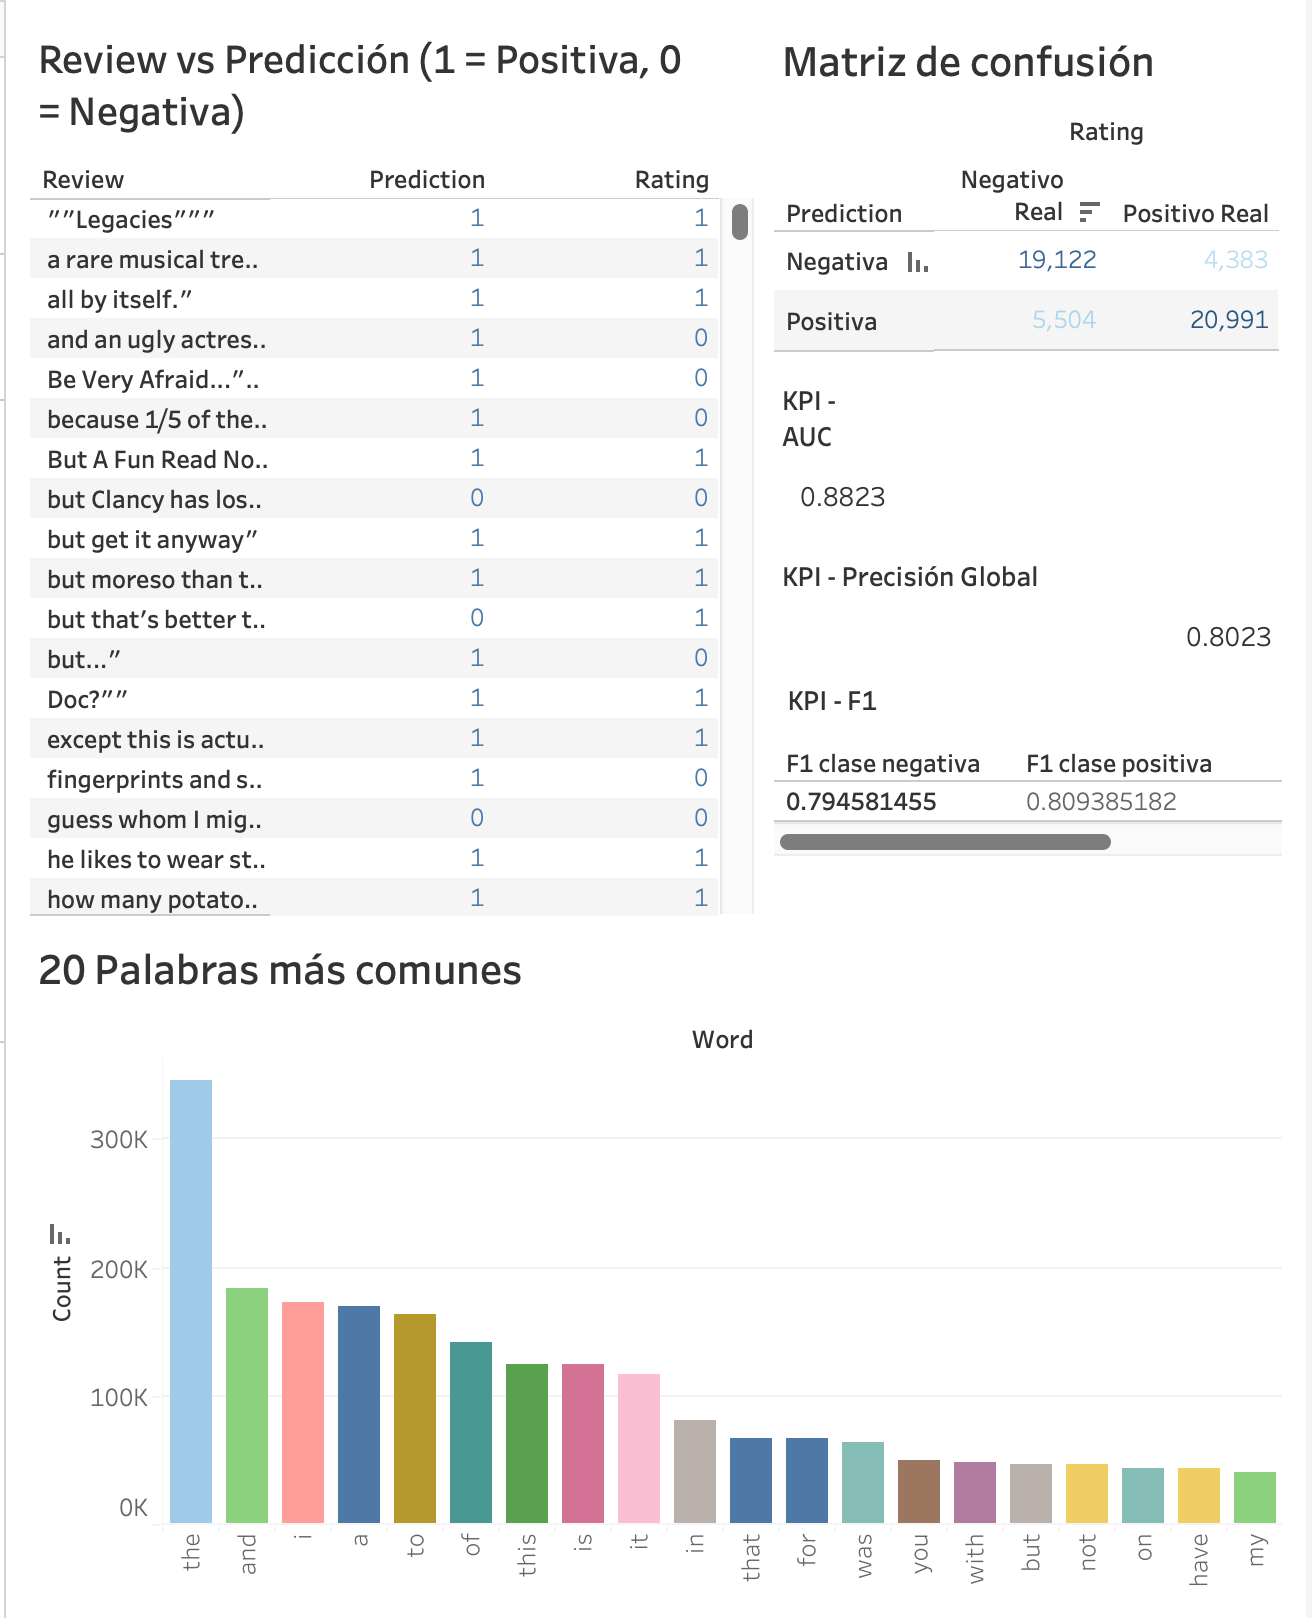

Este tablero nos permite visualizar los siguientes elementos:
- Visualizar reseñas de manera individual, y comparar la predicción contra el sentimiento real.
- Visualizar la matriz de confusión (Cuantas predicciones fueron acertadas por categoría)
- Una gráfica con las 20 palabras mas comunes.
- KPIs correspondientes al área bajo la curva (AUC), Precisión y F1-Score.